# Before you start :
   - These exercises are related to the Subsetting and Descriptive Stats lessons.
   - Keep in mind that you need to use some of the functions you learned in the previous lessons.
   - All datasets are provided in the `your-code` folder of this lab.
   - Elaborate your codes and outputs as much as you can.
   - Try your best to answer the questions and complete the tasks and most importantly enjoy the process!!!

#### Import all the libraries that are necessary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Challenge 1

#### In this challenge we will use the `Temp_States.csv` file. 

#### First import it into a data frame called `temp`.

In [4]:
temp = pd.read_csv("Temp_States.csv")
temp.head()

,City,State,Temperature
0,NYC,New York,19.444444
1,Albany,New York,9.444444
2,Buffalo,New York,3.333333
3,Hartford,Connecticut,17.222222
4,Bridgeport,Connecticut,14.444444


#### Print `temp`

In [5]:
temp

,City,State,Temperature
0,NYC,New York,19.444444
1,Albany,New York,9.444444
2,Buffalo,New York,3.333333
3,Hartford,Connecticut,17.222222
4,Bridgeport,Connecticut,14.444444
5,Treton,New Jersey,22.222222
6,Newark,New Jersey,20.000000


#### Explore the data types of the Temp dataframe. What type of data do we have? Comment your result.

In [7]:
temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   City         7 non-null      str    
 1   State        7 non-null      str    
 2   Temperature  7 non-null      float64
dtypes: float64(1), str(2)
memory usage: 300.0 bytes


* **We have 2 cotegorical datatype which are City and State;**
* **and we ave 1 numerical datatype which is Temperature**

In [9]:
temp.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,7.0,15.15873,6.695265,3.333333,11.944444,17.222222,19.722222,22.222222


#### Select the rows where state is New York

In [10]:
new_york = temp[temp["State"] == "New York"]
new_york

,City,State,Temperature
0,NYC,New York,19.444444
1,Albany,New York,9.444444
2,Buffalo,New York,3.333333


In [11]:
new_york.shape

(3, 3)

In [13]:
new_york.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,3.0,10.740741,8.133404,3.333333,6.388889,9.444444,14.444444,19.444444


#### What is the average of the temperature of cities in New York?

In [16]:
new_york_average_temp = new_york["Temperature"].mean()
new_york_average_temp

np.float64(10.74074074074074)

#### We want to know cities and states with Temperature above 15 degress Celcius

In [17]:
temp_above_15 = temp[temp["Temperature"] > 15]
temp_above_15[["City", "State", "Temperature"]]

,City,State,Temperature
0,NYC,New York,19.444444
3,Hartford,Connecticut,17.222222
5,Treton,New Jersey,22.222222
6,Newark,New Jersey,20.000000


#### Now, return only the cities that have a temperature above 15 degress Celcius

In [18]:
temp_above_15[["City", "Temperature"]]

,City,Temperature
0,NYC,19.444444
3,Hartford,17.222222
5,Treton,22.222222
6,Newark,20.000000


#### We want to know which cities have a temperature above 15 degrees Celcius and below 20 degrees Celcius

*Hint: First write the condition then select the rows.*

In [21]:
temp_above_15_20 = temp[(temp["Temperature"] > 15) & (temp["Temperature"] < 20)]
temp_above_15_20[["City", "Temperature"]]

,City,Temperature
0,NYC,19.444444
3,Hartford,17.222222


In [24]:
temp['State'].value_counts()

State
New York       3
Connecticut    2
New Jersey     2
Name: count, dtype: int64

#### Find the mean and the standard deviation of the temperature of each state.

*Hint: Use functions from Data Manipulation lesson*

In [26]:
state_stats = temp.groupby("State")["Temperature"].agg(["mean", "std"])
state_stats.T

State,Connecticut,New Jersey,New York
mean,15.833333,21.111111,10.740741
std,1.964186,1.571348,8.133404


# Challenge 2

#### Load the `employee.csv` file into a DataFrame. Call the dataframe `employee`

In [28]:
employee = pd.read_csv("Employee.csv")
employee.head()

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30
3,Sonia,HR,Bachelor,F,analyst,4,35
4,Samuel,Sales,Master,M,associate,3,55


#### Explore the data types of the Temp dataframe. Comment your results

In [30]:
employee.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        9 non-null      str  
 1   Department  9 non-null      str  
 2   Education   9 non-null      str  
 3   Gender      9 non-null      str  
 4   Title       9 non-null      str  
 5   Years       9 non-null      int64
 6   Salary      9 non-null      int64
dtypes: int64(2), str(5)
memory usage: 636.0 bytes


* **We have 5 cotegorical datatypes which are Name, Departement, Education, Gender and Title;**
* **We ave 1 numerical datatype which is Salary;**
*  **And depending on our purposes, we can use "Years" as Numerical or Categorical DataType**

In [35]:
employee.describe().T

,count,mean,std,min,25%,50%,75%,max
Years,9.0,4.111111,2.803767,1.0,2.0,3.0,7.0,8.0
Salary,9.0,48.888889,16.541194,30.0,35.0,55.0,60.0,70.0


In [37]:
employee.shape

(9, 7)

#### Show visually the frequency distribution (histogram) of the employee dataset. In few words describe these histograms?

#### Short Interpretation of the Histograms
##### Years of Experience
* The distribution typically shows more employees with fewer years of experience.

##### Salary
* Most employees earn in the higher-to-mid salary range.

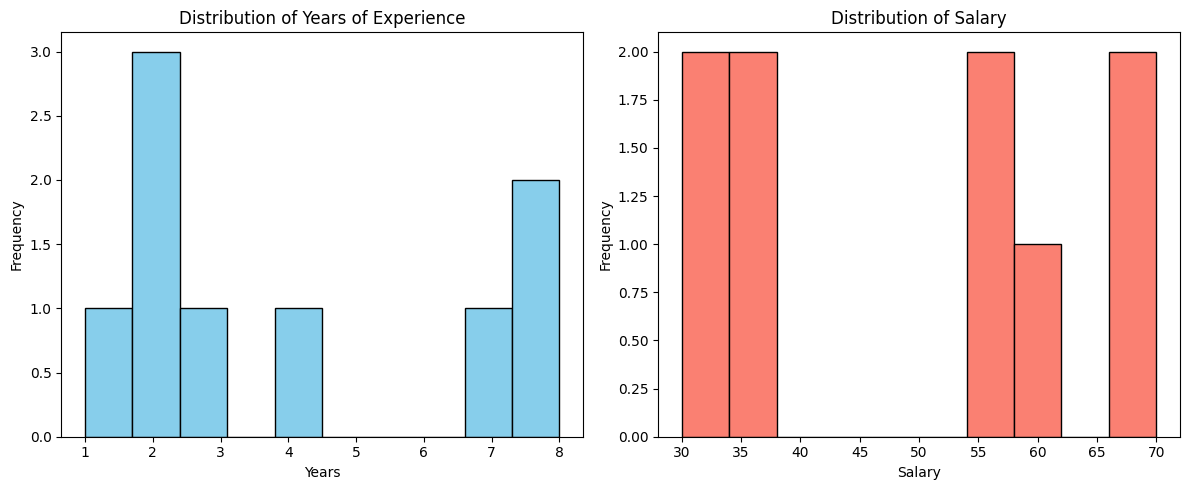

In [44]:
plt.figure(figsize=(12,5))

# Histogram for Years
plt.subplot(1, 2, 1)
plt.hist(employee["Years"], bins=10, color="skyblue", edgecolor="black")
plt.title("Distribution of Years of Experience")
plt.xlabel("Years")
plt.ylabel("Frequency")

# Histogram for Salary
plt.subplot(1, 2, 2)
plt.hist(employee["Salary"], bins=10, color="salmon", edgecolor="black")
plt.title("Distribution of Salary")
plt.xlabel("Salary")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# YOUR CODE HERE

#### What's the average salary in this company?

In [47]:
print(f"The average salary in this company is {employee["Salary"].mean()}")

The average salary in this company is 48.888888888888886


#### What's the highest salary?

In [48]:
print(f"The highest salary is {employee["Salary"].max()}")

The highest salary is 70


#### What's the lowest salary?

In [49]:
print(f"The lowest salary is {employee["Salary"].min()}")

The lowest salary is 30


#### Who are the employees with the lowest salary?

In [55]:
print(f"The employees with the lowest salary are \n\n{employee[employee["Salary"] == employee["Salary"].min()]}")

The employees with the lowest salary are 

    Name Department Education Gender    Title  Years  Salary
1  Maria         IT    Master      F  analyst      2      30
2  David         HR    Master      M  analyst      2      30


#### Could you give all the information about an employee called David?

In [56]:
employee[employee["Name"] == "David"]

,Name,Department,Education,Gender,Title,Years,Salary
2,David,HR,Master,M,analyst,2,30


#### Could you give only David's salary?

In [62]:
print(f"David earns {employee.loc[employee["Name"] == "David", "Salary"].iloc[0]}K a year")

David earns 30K a year


#### Print all the rows where job title is associate

In [64]:
employee[employee["Title"] == "associate"]

,Name,Department,Education,Gender,Title,Years,Salary
4,Samuel,Sales,Master,M,associate,3,55
5,Eva,Sales,Bachelor,F,associate,2,55
7,Pedro,IT,Phd,M,associate,7,60


#### Print the first 3 rows of your dataframe

##### Tip : There are 2 ways to do it. Do it both ways

In [65]:
employee.head(3)

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30


In [66]:
employee[:3]

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30


#### Find the employees who's title is associate and the salary above 55?

In [67]:
employee[(employee["Title"] == "associate") & (employee["Salary"] == 55)]

,Name,Department,Education,Gender,Title,Years,Salary
4,Samuel,Sales,Master,M,associate,3,55
5,Eva,Sales,Bachelor,F,associate,2,55


#### Group the employees based on their number of years of employment. What are the average salaries in each group?

In [70]:
employee.groupby("Years")["Salary"].mean()

Years
1    35.000000
2    38.333333
3    55.000000
4    35.000000
7    60.000000
8    70.000000
Name: Salary, dtype: float64

####  What is the average Salary per title?

In [71]:
employee.groupby("Title")["Salary"].mean()

Title
VP           70.000000
analyst      32.500000
associate    56.666667
Name: Salary, dtype: float64

#### Show a visual summary of the data using boxplot. What Are the First and Third Quartiles? Comment your results.

* Hint : Quantiles vs Quartiles*
In Probability and Statistics, quantiles are cut points dividing the range of a probability distribution into continuous intervals with equal probabilities. When division is into four parts the values of the variate corresponding to 25%, 50% and 75% of the total distribution are called quartiles.

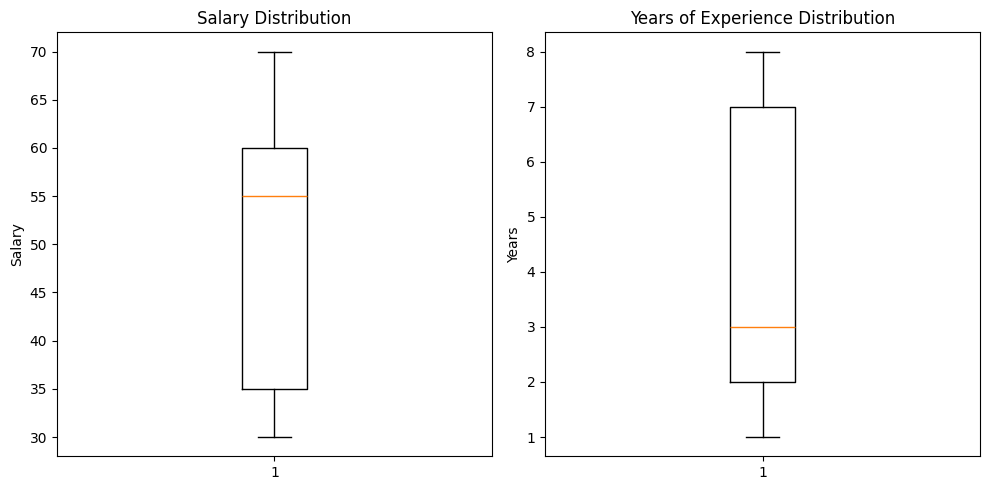

In [75]:
plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.boxplot(employee["Salary"])
plt.title("Salary Distribution")
plt.ylabel("Salary")

plt.subplot(1, 2, 2)
plt.boxplot(employee["Years"])
plt.title("Years of Experience Distribution")
plt.ylabel("Years")

plt.tight_layout()
plt.show()

In [78]:
q1_salary = employee["Salary"].quantile(0.25)

q1_years = employee["Years"].quantile(0.25)

print(f"The first quartile for salary is {q1_salary} and for years experience is {q1_years}")

The first quartile for salary is 35.0 and for years experience is 2.0


In [79]:
q3_salary = employee["Salary"].quantile(0.75)
q3_years = employee["Years"].quantile(0.75)

print(f"The third quartile for salary is {q3_salary} and for years experience is {q3_years}")

The third quartile for salary is 60.0 and for years experience is 7.0


In [84]:
print("IQR_SALARY = ", q3_salary - q1_salary)

IQR_SALARY =  25.0


In [85]:
print("IQR_YEARS = ", q3_years - q1_years)

IQR_YEARS =  5.0


#### Interpretation (Comment on the Results)
##### Salary Boxplot
* `q1_salary` (25%): 25% of employees earn below this salary.
* `q3_salary` (75%): 75% of employees earn below this salary.
* The IQR (`q3_salary` − `q1_salary`) shows the middle spread of salaries.
* If the upper whisker is long or there are dots above it, that indicates high‑earning outliers.

##### Years of Experience Boxplot
* `q1_years` and `q3_years` show how experience is distributed.
* If `q1_years` is low and `q3_years` is not too high, it means most employees are early‑career.

#### Is the mean salary per gender different?

In [90]:
print ("Yes, the mean salary per gender is different as we can see below \n\n", employee.groupby("Gender")["Salary"].mean())

Yes, the mean salary per gender is different as we can see below 

 Gender
F    47.5
M    50.0
Name: Salary, dtype: float64


#### Find the minimum, mean and the maximum of all numeric columns for each Department.

##### Hint: Use functions from Data Manipulation lesson

In [96]:
employee.groupby("Department")[["Salary", "Years"]].agg(["min", "mean", "max"]).T

Department          HR     IT  Sales
Salary min   30.000000  30.00   55.0
       mean  45.000000  48.75   55.0
       max   70.000000  70.00   55.0
Years  min    2.000000   1.00    2.0
       mean   4.666667   4.50    2.5
       max    8.000000   8.00    3.0

### Bonus Question

#### For each department, compute the difference between the maximal salary and the minimal salary.

##### * Hint: try using `agg` or `apply` and `lambda`*

In [99]:
employee.groupby("Department")["Salary"].agg(lambda x: x.max() - x.min())

Department
HR       40
IT       40
Sales     0
Name: Salary, dtype: int64

In [100]:
employee.groupby("Department")["Salary"].apply(lambda x: x.max() - x.min())

Department
HR       40
IT       40
Sales     0
Name: Salary, dtype: int64

# Challenge 3

#### Open the Orders.csv dataset. Name your dataset orders

In [141]:
orders = pd.read_csv("Orders.csv")

In [142]:
orders = orders.drop(columns=["Unnamed: 0"])
orders["InvoiceDate"] = pd.to_datetime(orders["InvoiceDate"])
orders = orders.dropna(subset=["CustomerID"])
orders = orders[orders["Description"].notna()]
orders = orders[orders["Description"].str.strip() != ""]
orders["amount_spent"] = orders["Quantity"] * orders["UnitPrice"]
orders = orders.drop_duplicates()

#### Explore your dataset by looking at the data types and the summary statistics. Comment your results

In [113]:
orders.dtypes

InvoiceNo                int64
StockCode                  str
year                     int64
month                    int64
day                      int64
hour                     int64
Description                str
Quantity                 int64
InvoiceDate     datetime64[us]
UnitPrice              float64
CustomerID               int64
Country                    str
amount_spent           float64
dtype: object

In [114]:
orders.describe().T

,count,mean,min,25%,50%,75%,max,std
InvoiceNo,392692.0,560590.875047,536365.0,549234.0,561874.0,572061.0,581587.0,13087.063759
year,392692.0,2010.934631,2010.0,2011.0,2011.0,2011.0,2011.0,0.247177
month,392692.0,7.601871,1.0,5.0,8.0,11.0,12.0,3.415015
day,392692.0,3.606911,1.0,2.0,3.0,5.0,7.0,1.923929
hour,392692.0,12.721532,6.0,11.0,13.0,14.0,20.0,2.276661
Quantity,392692.0,13.119702,1.0,2.0,6.0,12.0,80995.0,180.492832
InvoiceDate,392692,2011-07-10 19:13:07.771892,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392692.0,3.125914,0.001,1.25,1.95,3.75,8142.75,22.241836
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549
amount_spent,392692.0,22.6315,0.001,4.95,12.45,19.8,168469.6,311.099224


In [117]:
orders.head()

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
0,536365,85123A,2010,12,3,8,white hanging heart t-light holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,2010,12,3,8,white metal lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,2010,12,3,8,cream cupid hearts coat hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,2010,12,3,8,knitted union flag hot water bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,2010,12,3,8,red woolly hottie white heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


####  What is the average Purchase Price?

In [118]:
orders["UnitPrice"].mean()

np.float64(3.1259139070823956)

In [119]:
orders["amount_spent"].mean()

np.float64(22.631499735161402)

#### What were the highest and lowest purchase prices? 

In [120]:
orders["UnitPrice"].min(), orders["UnitPrice"].max()

(np.float64(0.001), np.float64(8142.75))

In [121]:
orders["amount_spent"].min(), orders["amount_spent"].max()

(np.float64(0.001), np.float64(168469.6))

#### Select all the customers we have in Spain

In [131]:
orders_Spain = orders[orders["Country"] == "Spain"]
orders_Spain.head()

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
4250,536944,22383,2010,12,5,12,lunch bag suki design,70,2010-12-03 12:20:00,1.65,12557,Spain,115.5
4251,536944,22384,2010,12,5,12,lunch bag pink polkadot,100,2010-12-03 12:20:00,1.45,12557,Spain,145.0
4252,536944,20727,2010,12,5,12,lunch bag black skull.,60,2010-12-03 12:20:00,1.65,12557,Spain,99.0
4253,536944,20725,2010,12,5,12,lunch bag red retrospot,70,2010-12-03 12:20:00,1.65,12557,Spain,115.5
4254,536944,20728,2010,12,5,12,lunch bag cars blue,100,2010-12-03 12:20:00,1.45,12557,Spain,145.0


#### How many customers do we have in Spain?
##### Hint : Use value_counts()

In [128]:
orders_Spain["CustomerID"].nunique()

30

#### Select all the customers who have bought more than 50 items ?

In [135]:
customers_more_than_50_items = orders.groupby("CustomerID")["Quantity"].sum().loc[lambda x: x > 50]

print(customers_more_than_50_items)

CustomerID
12346    74215
12347     2458
12348     2341
12349      631
12350      197
         ...  
18278       66
18281       54
18282      103
18283     1357
18287     1586
Name: Quantity, Length: 4089, dtype: int64


#### Select orders from Spain that are above 50 items

In [137]:
orders_spain_above_50_items = orders[(orders["Country"] == "Spain") & (orders["Quantity"] > 50)]

orders_spain_above_50_items

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
4250,536944,22383,2010,12,5,12,lunch bag suki design,70,2010-12-03 12:20:00,1.65,12557,Spain,115.50
4251,536944,22384,2010,12,5,12,lunch bag pink polkadot,100,2010-12-03 12:20:00,1.45,12557,Spain,145.00
4252,536944,20727,2010,12,5,12,lunch bag black skull.,60,2010-12-03 12:20:00,1.65,12557,Spain,99.00
4253,536944,20725,2010,12,5,12,lunch bag red retrospot,70,2010-12-03 12:20:00,1.65,12557,Spain,115.50
4254,536944,20728,2010,12,5,12,lunch bag cars blue,100,2010-12-03 12:20:00,1.45,12557,Spain,145.00
32454,540785,84997B,2011,1,2,11,red 3 piece retrospot cutlery set,144,2011-01-11 11:39:00,3.39,12557,Spain,488.16
32455,540785,84997D,2011,1,2,11,pink 3 piece polkadot cutlery set,360,2011-01-11 11:39:00,3.39,12557,Spain,1220.40
32456,540785,84997C,2011,1,2,11,blue 3 piece polkadot cutlery set,360,2011-01-11 11:39:00,3.39,12557,Spain,1220.40
32457,540785,84997A,2011,1,2,11,green 3 piece polkadot cutlery set,144,2011-01-11 11:39:00,3.39,12557,Spain,488.16
91155,547972,22383,2011,3,1,16,lunch bag suki design,150,2011-03-28 16:41:00,1.45,12557,Spain,217.50


#### Select all free orders

In [144]:
orders[orders["UnitPrice"] == 0]

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
6914,537197,22841,2010,12,7,14,round cake tin vintage green,1,2010-12-05 14:02:00,0.0,12647,Germany,0.0
22539,539263,22580,2010,12,4,14,advent calendar gingham sack,4,2010-12-16 14:36:00,0.0,16560,United Kingdom,0.0
25379,539722,22423,2010,12,2,13,regency cakestand 3 tier,10,2010-12-21 13:45:00,0.0,14911,EIRE,0.0
29080,540372,22090,2011,1,4,16,paper bunting retrospot,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
29082,540372,22553,2011,1,4,16,plasters in tin skulls,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
34494,541109,22168,2011,1,4,15,organiser wood antique white,1,2011-01-13 15:10:00,0.0,15107,United Kingdom,0.0
53788,543599,84535B,2011,2,4,13,fairy cakes notebook a6 size,16,2011-02-10 13:08:00,0.0,17560,United Kingdom,0.0
85671,547417,22062,2011,3,3,10,ceramic bowl with love heart design,36,2011-03-23 10:25:00,0.0,13239,United Kingdom,0.0
92875,548318,22055,2011,3,3,12,mini cake stand hanging strawbery,5,2011-03-30 12:45:00,0.0,13113,United Kingdom,0.0
97430,548871,22162,2011,4,1,14,heart garland rustic padded,2,2011-04-04 14:42:00,0.0,14410,United Kingdom,0.0


In [145]:
orders[orders["amount_spent"] == 0]

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
6914,537197,22841,2010,12,7,14,round cake tin vintage green,1,2010-12-05 14:02:00,0.0,12647,Germany,0.0
22539,539263,22580,2010,12,4,14,advent calendar gingham sack,4,2010-12-16 14:36:00,0.0,16560,United Kingdom,0.0
25379,539722,22423,2010,12,2,13,regency cakestand 3 tier,10,2010-12-21 13:45:00,0.0,14911,EIRE,0.0
29080,540372,22090,2011,1,4,16,paper bunting retrospot,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
29082,540372,22553,2011,1,4,16,plasters in tin skulls,24,2011-01-06 16:41:00,0.0,13081,United Kingdom,0.0
34494,541109,22168,2011,1,4,15,organiser wood antique white,1,2011-01-13 15:10:00,0.0,15107,United Kingdom,0.0
53788,543599,84535B,2011,2,4,13,fairy cakes notebook a6 size,16,2011-02-10 13:08:00,0.0,17560,United Kingdom,0.0
85671,547417,22062,2011,3,3,10,ceramic bowl with love heart design,36,2011-03-23 10:25:00,0.0,13239,United Kingdom,0.0
92875,548318,22055,2011,3,3,12,mini cake stand hanging strawbery,5,2011-03-30 12:45:00,0.0,13113,United Kingdom,0.0
97430,548871,22162,2011,4,1,14,heart garland rustic padded,2,2011-04-04 14:42:00,0.0,14410,United Kingdom,0.0


#### Select all orders that are 'lunch bag'
#### Hint: Use string functions

In [146]:
orders[orders["Description"].str.contains("lunch bag", case=False, na=False)]

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
93,536378,20725,2010,12,3,9,lunch bag red retrospot,10,2010-12-01 09:37:00,1.65,14688,United Kingdom,16.50
172,536385,22662,2010,12,3,9,lunch bag dolly girl design,10,2010-12-01 09:56:00,1.65,17420,United Kingdom,16.50
354,536401,22662,2010,12,3,11,lunch bag dolly girl design,1,2010-12-01 11:21:00,1.65,15862,United Kingdom,1.65
359,536401,20725,2010,12,3,11,lunch bag red retrospot,1,2010-12-01 11:21:00,1.65,15862,United Kingdom,1.65
360,536401,22382,2010,12,3,11,lunch bag spaceboy design,2,2010-12-01 11:21:00,1.65,15862,United Kingdom,3.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397465,581486,23207,2011,12,5,9,lunch bag alphabet design,10,2011-12-09 09:38:00,1.65,17001,United Kingdom,16.50
397713,581538,20727,2011,12,5,11,lunch bag black skull.,1,2011-12-09 11:34:00,1.65,14446,United Kingdom,1.65
397714,581538,20725,2011,12,5,11,lunch bag red retrospot,1,2011-12-09 11:34:00,1.65,14446,United Kingdom,1.65
397877,581581,23681,2011,12,5,12,lunch bag red vintage doily,10,2011-12-09 12:20:00,1.65,17581,United Kingdom,16.50


#### Select all orders that are made in 2011 and are 'lunch bag'  

In [148]:
orders[(orders["Description"].str.contains("lunch bag", case=False, na=False)) & (orders["year"] == 2011)]

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
26340,540015,20725,2011,1,2,11,lunch bag red retrospot,10,2011-01-04 11:40:00,1.65,13319,United Kingdom,16.50
26341,540015,20726,2011,1,2,11,lunch bag woodland,10,2011-01-04 11:40:00,1.65,13319,United Kingdom,16.50
26512,540023,22382,2011,1,2,12,lunch bag spaceboy design,2,2011-01-04 12:58:00,1.65,15039,United Kingdom,3.30
26513,540023,20726,2011,1,2,12,lunch bag woodland,1,2011-01-04 12:58:00,1.65,15039,United Kingdom,1.65
26860,540098,22384,2011,1,2,15,lunch bag pink polkadot,1,2011-01-04 15:50:00,1.65,16241,United Kingdom,1.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
397465,581486,23207,2011,12,5,9,lunch bag alphabet design,10,2011-12-09 09:38:00,1.65,17001,United Kingdom,16.50
397713,581538,20727,2011,12,5,11,lunch bag black skull.,1,2011-12-09 11:34:00,1.65,14446,United Kingdom,1.65
397714,581538,20725,2011,12,5,11,lunch bag red retrospot,1,2011-12-09 11:34:00,1.65,14446,United Kingdom,1.65
397877,581581,23681,2011,12,5,12,lunch bag red vintage doily,10,2011-12-09 12:20:00,1.65,17581,United Kingdom,16.50


#### Show the frequency distribution of the amount spent in Spain.

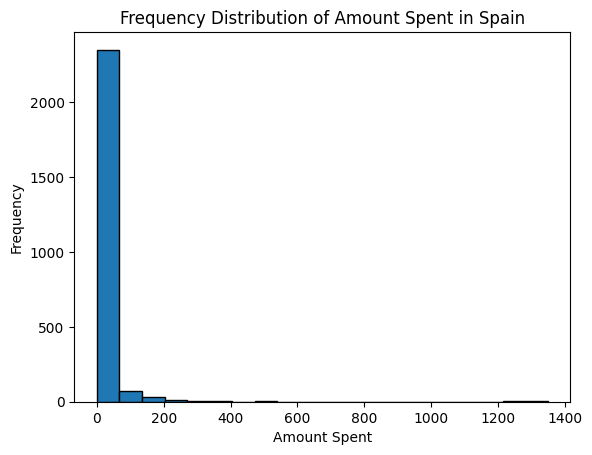

In [150]:
spain_data = orders[orders["Country"] == "Spain"]["amount_spent"]

plt.hist(spain_data, bins=20, edgecolor="black")
plt.title("Frequency Distribution of Amount Spent in Spain")
plt.xlabel("Amount Spent")
plt.ylabel("Frequency")
plt.show()

#### Select all orders made in the month of August

In [151]:
orders[orders["month"] == 8]

,InvoiceNo,StockCode,year,month,day,hour,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,amount_spent
199475,561904,22075,2011,8,1,8,6 ribbons elegant christmas,96,2011-08-01 08:30:00,1.45,17941,United Kingdom,139.20
199476,561904,85049E,2011,8,1,8,scandinavian reds ribbons,156,2011-08-01 08:30:00,1.06,17941,United Kingdom,165.36
199477,561905,21385,2011,8,1,9,ivory hanging decoration heart,24,2011-08-01 09:31:00,0.85,14947,United Kingdom,20.40
199478,561905,84970L,2011,8,1,9,single heart zinc t-light holder,12,2011-08-01 09:31:00,0.95,14947,United Kingdom,11.40
199479,561905,84970S,2011,8,1,9,hanging heart zinc t-light holder,12,2011-08-01 09:31:00,0.85,14947,United Kingdom,10.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...
226483,565067,22644,2011,8,3,17,ceramic cherry cake money bank,2,2011-08-31 17:16:00,1.45,15856,United Kingdom,2.90
226484,565067,22645,2011,8,3,17,ceramic heart fairy cake money bank,2,2011-08-31 17:16:00,1.45,15856,United Kingdom,2.90
226485,565067,22637,2011,8,3,17,piggy bank retrospot,2,2011-08-31 17:16:00,2.55,15856,United Kingdom,5.10
226486,565067,22646,2011,8,3,17,ceramic strawberry cake money bank,2,2011-08-31 17:16:00,1.45,15856,United Kingdom,2.90


In [155]:
orders[orders["month"] == 8].shape

(26796, 13)

#### Select how many orders are made by countries in the month of August
##### Hint: Use value_counts()

In [159]:
orders[orders["month"] == 8]["Country"].value_counts()

Country
United Kingdom     22895
Germany              795
EIRE                 590
France               569
Netherlands          280
Switzerland          267
Spain                250
Belgium              194
Israel               171
Channel Islands      139
Australia            107
Italy                 95
Austria               88
Norway                77
Finland               61
Malta                 55
Portugal              41
Sweden                39
Unspecified           23
Iceland               22
Poland                17
Denmark               16
Canada                 5
Name: count, dtype: int64

#### What's the  average amount of money spent by country

In [161]:
orders.groupby("Country")["amount_spent"].mean()

Country
Australia               116.937340
Austria                  25.624824
Bahrain                  32.258824
Belgium                  20.283772
Brazil                   35.737500
Canada                   24.280662
Channel Islands          27.363507
Cyprus                   22.392786
Czech Republic           33.069600
Denmark                  49.882474
EIRE                     36.699289
European Community       21.670833
Finland                  32.913985
France                   25.091187
Germany                  25.332713
Greece                   32.831172
Iceland                  23.681319
Israel                   29.452408
Italy                    23.064960
Japan                   116.561900
Lebanon                  37.641778
Lithuania                47.458857
Malta                    24.335625
Netherlands             120.798282
Norway                   33.736418
Poland                   22.226212
Portugal                 22.970296
RSA                      17.281207
Saudi Arabia

#### What's the most expensive item?

In [164]:
orders.loc[orders["UnitPrice"].idxmax()]

InvoiceNo                    551697
StockCode                      POST
year                           2011
month                             5
day                               2
hour                             13
Description                 postage
Quantity                          1
InvoiceDate     2011-05-03 13:46:00
UnitPrice                   8142.75
CustomerID                    16029
Country              United Kingdom
amount_spent                8142.75
Name: 118352, dtype: object

#### What was the average amount spent per year ?

In [167]:
orders.groupby("year")["amount_spent"].mean()

year
2010    22.21878
2011    22.65790
Name: amount_spent, dtype: float64